# 01 · Synthetic validation

**Part 1 — canonical 2×2 DiD and the parallel-trends check.**

This notebook is the project's *proof-of-correctness*, and it is built before
any real data touches the repository (`PROJECT_BRIEF.md` §6, §9.2).

The logic: on real observational data the true causal effect is unknown, so a
DiD estimate cannot be checked — only believed. So we first build a synthetic
panel where the true effect is **planted by construction**, and demand that the
estimator recover it. If the machinery cannot recover an effect we placed
ourselves, it has no business being pointed at messy real data.

**All data in this notebook is synthetic and clearly labelled as such.**

### The gates

| Gate | Requirement |
|------|-------------|
| 1 | The 2×2 DiD estimate recovers the planted ATT **within its confidence interval** |
| 2 | The regression estimator equals the hand-computed group-means DiD |
| 3 | The pre-trends test **passes** on a pre-period where parallel trends holds by construction |

Each gate is an executable `assert`. If a gate breaks, this notebook fails loudly
rather than quietly reporting a wrong number.

In [1]:
import sys
from pathlib import Path

# Resolve the repo root whether this is run from notebooks/ or the repo root.
_here = Path.cwd()
ROOT = next(p for p in (_here, _here.parent) if (p / "src" / "config.py").exists())
sys.path.insert(0, str(ROOT / "src"))

from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import config
from generate_panel import PanelParams, generate_simple_panel
from did import did_2x2, pretrends_test

# Single source of reproducibility: the committed seed from src/config.py.
config.set_global_seeds()
RESULTS = config.RESULTS_DIR

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10,
})

TREATED_C, CONTROL_C = "#c1272d", "#2b6cb0"
print(f"project seed : {config.SEED}")
print(f"results dir  : {RESULTS}")

project seed : 20260620
results dir  : C:\Users\rober\Infinity Castle\Portfolio\Project 2\host-city-economics\results


## 1. The synthetic panel

The simple case first: a balanced panel of cities observed over 12 periods,
with a **single** treatment date and a never-treated control group.

The data-generating process is the textbook DiD model:

$$y_{it} = \text{base} + \alpha_i + \lambda_t + \tau \cdot D_{it} + \varepsilon_{it}, \qquad D_{it} = \mathbb{1}[i \text{ treated}] \cdot \mathbb{1}[t \geq t_0]$$

Two properties hold **by construction**, and they are the whole point:

- **Parallel trends holds.** Treated and control cities share the *same* time
  effects $\lambda_t$ and there is no group-specific trend. Absent treatment
  their expected paths move in parallel — so the pre-period is a clean test bed,
  and a correct pre-trends test *should* pass on it.
- **The ATT is exactly $\tau$.** The effect is homogeneous across treated cities
  and post-periods, so there is no aggregation subtlety between "the ATT" and
  "the planted constant".

Every generating parameter lives in `PanelParams` in `src/generate_panel.py` and
is committed. The notebook reads the planted effect back from the parameters
rather than restating it, so the truth it checks against cannot drift out of sync.

Outcome units are illustrative: read $y$ as metro leisure & hospitality
employment in thousands of jobs, the real outcome from Stage 3 onward.

In [2]:
params = PanelParams()
panel = generate_simple_panel(params)

TRUE_ATT = panel.attrs["true_att"]   # read the truth back, never hardcode it

print(f"cities        : {params.n_cities}  ({params.n_treated} treated / "
      f"{params.n_cities - params.n_treated} control)")
print(f"periods       : {params.n_periods}  "
      f"({params.n_pre_periods} pre, {params.n_post_periods} post)")
print(f"treat period  : {params.treat_period}")
print(f"noise SD      : {params.sd_noise}")
print(f"seed          : {params.seed}")
print(f"PLANTED ATT   : {TRUE_ATT}")
print(f"panel shape   : {panel.shape}")
panel.head()

cities        : 50  (25 treated / 25 control)
periods       : 12  (6 pre, 6 post)
treat period  : 7
noise SD      : 2.0
seed          : 20260620
PLANTED ATT   : 3.0
panel shape   : (600, 8)


,city,period,treated,post,d,cohort,true_effect,y
0,city_00,1,0,0,0,NaN,0.0,101.934498
1,city_00,2,0,0,0,NaN,0.0,105.880890
2,city_00,3,0,0,0,NaN,0.0,103.145307
3,city_00,4,0,0,0,NaN,0.0,101.139147
4,city_00,5,0,0,0,NaN,0.0,108.499273


### Save the panel

The synthetic panel is committed to `data/` so the validation is reproducible
from a clean checkout without re-running the generator (`PROJECT_BRIEF.md` §6).

In [3]:
config.DATA_DIR.mkdir(parents=True, exist_ok=True)
panel_path = config.DATA_DIR / "synthetic_panel_simple.csv"
panel.to_csv(panel_path, index=False)
print(f"wrote {panel_path.relative_to(ROOT)}  ({panel.shape[0]} rows)")

wrote data\synthetic_panel_simple.csv  (600 rows)


## 2. The DiD picture

Before estimating anything, look at it. This is the difference-in-differences
design in one chart: two groups moving in parallel, then one of them steps up
when treatment arrives.

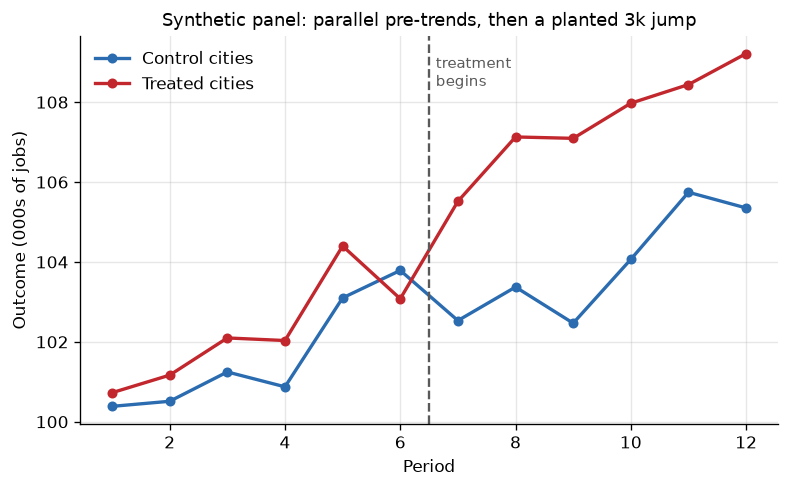

In [4]:
means = panel.groupby(["period", "treated"])["y"].mean().unstack()

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(means.index, means[0], "o-", color=CONTROL_C, lw=2, ms=5, label="Control cities")
ax.plot(means.index, means[1], "o-", color=TREATED_C, lw=2, ms=5, label="Treated cities")
ax.axvline(params.treat_period - 0.5, color="0.35", ls="--", lw=1.4)
ax.annotate("treatment\nbegins", xy=(params.treat_period - 0.5, ax.get_ylim()[1]),
            xytext=(4, -30), textcoords="offset points", fontsize=9,
            color="0.35", ha="left")
ax.set_xlabel("Period")
ax.set_ylabel("Outcome (000s of jobs)")
ax.set_title(f"Synthetic panel: parallel pre-trends, then a planted "
             f"{TRUE_ATT:g}k jump", fontsize=11)
ax.legend(frameon=False, loc="upper left")
fig.savefig(RESULTS / "01_synthetic_group_means.png")
plt.show()

## 3. Gate 1 — does the 2×2 DiD recover the planted ATT?

The canonical 2×2 estimator fits

$$y_{it} = \beta_0 + \beta_1 \text{treated}_i + \beta_2 \text{post}_t + \beta_3 (\text{treated}_i \times \text{post}_t) + \varepsilon_{it}$$

and $\beta_3$ is the DiD estimate. Standard errors are **clustered on city**:
DiD residuals are serially correlated within a unit, and unclustered standard
errors are badly anti-conservative in that setting.

**The gate: the confidence interval must cover the planted ATT.**

In [5]:
res = did_2x2(
    panel,
    outcome="y", unit="city", time="period", treated="treated",
    treat_period=params.treat_period,
)
print(res.summary(planted=TRUE_ATT))

# GATE 1 — fail loudly, do not explain away.
assert res.contains(TRUE_ATT), (
    f"GATE 1 FAILED: {(1-res.alpha)*100:.0f}% CI "
    f"[{res.ci_lower:.4f}, {res.ci_upper:.4f}] does not cover planted ATT {TRUE_ATT}"
)
print("\nGATE 1 PASS - CI covers the planted ATT")

Canonical 2x2 DiD
  ATT estimate     : +3.0407
  Std. error       : 0.2616 (clustered by unit)
  t / p            : +11.623 / 3.137e-31
  95% CI           : [+2.5280, +3.5535]
  N                : 600 obs, 50 units (25 treated)
  Planted ATT      : +3.0000
  Recovery error   : +0.0407
  CI covers truth  : YES

GATE 1 PASS - CI covers the planted ATT


## 4. Gate 2 — is the estimator actually a difference-in-differences?

A regression coefficient recovering the right number is *necessary* but not
sufficient: it could be right by accident. The 2×2 DiD has a closed form, so we
can check the implementation directly against it:

$$\widehat{\text{ATT}} = (\bar{y}^{\,\text{treat}}_{\text{post}} - \bar{y}^{\,\text{treat}}_{\text{pre}}) - (\bar{y}^{\,\text{ctrl}}_{\text{post}} - \bar{y}^{\,\text{ctrl}}_{\text{pre}})$$

The regression coefficient must equal this to machine precision.

In [6]:
g = panel.groupby(["treated", "post"])["y"].mean().unstack()
g.index = ["Control", "Treated"]; g.columns = ["Pre", "Post"]
display(g.round(4))

manual = (g.loc["Treated", "Post"] - g.loc["Treated", "Pre"]) \
       - (g.loc["Control", "Post"] - g.loc["Control", "Pre"])

print(f"hand-computed group-means DiD : {manual:.10f}")
print(f"regression coefficient        : {res.att:.10f}")
print(f"difference                    : {res.att - manual:.2e}")

# GATE 2
assert np.isclose(res.att, manual, atol=1e-10), (
    f"GATE 2 FAILED: regression ({res.att}) != group-means DiD ({manual})"
)
print("\nGATE 2 PASS - the estimator is a difference-in-differences")

,Pre,Post
Control,101.6512,103.9224
Treated,102.2503,107.5623


hand-computed group-means DiD : 3.0407269212
regression coefficient        : 3.0407269212
difference                    : 1.87e-14

GATE 2 PASS - the estimator is a difference-in-differences


## 5. Gate 3 — does the pre-trends test pass?

Parallel trends is the assumption the entire design rests on. It is not testable
directly (it concerns an unobserved counterfactual), but its observable
implication is: **before treatment, treated and control should not be diverging.**

Using pre-treatment observations only — so the test cannot be contaminated by
the treatment effect itself — we estimate a treated-vs-control gap for each
pre-period relative to a base period, and jointly test that all of them are zero.

Note the direction of the logic: this is a test we hope to **fail to reject**.
Passing is an *absence of evidence against* parallel trends, not proof of it.

In [7]:
pt = pretrends_test(
    panel,
    outcome="y", unit="city", time="period", treated="treated",
    treat_period=params.treat_period,
)
print(pt.summary())
print()
display(pt.leads.round(4))

# GATE 3
assert pt.passes, (
    f"GATE 3 FAILED: joint pre-trends test rejects "
    f"(F={pt.joint_stat:.3f}, p={pt.joint_pvalue:.4f})"
)
print("GATE 3 PASS - no evidence of differential pre-trends")

Pre-trends (parallel-trends) test
  Base period      : 6
  Leads tested     : 5
  Joint F          : 1.5158
  Joint p-value    : 0.2022
  Verdict (a=0.05) : PASS - no evidence of differential pre-trends



,period,relative_period,estimate,se,ci_lower,ci_upper,is_base
0,1.0,-6.0,1.0514,0.8441,-0.6029,2.7057,False
1,2.0,-5.0,1.3638,0.8803,-0.3616,3.0893,False
2,3.0,-4.0,1.5608,0.9046,-0.2121,3.3337,False
3,4.0,-3.0,1.8682,0.8128,0.2751,3.4612,False
4,5.0,-2.0,2.0085,0.8608,0.3213,3.6956,False
5,6.0,-1.0,0.0000,0.0000,0.0000,0.0000,True


GATE 3 PASS - no evidence of differential pre-trends


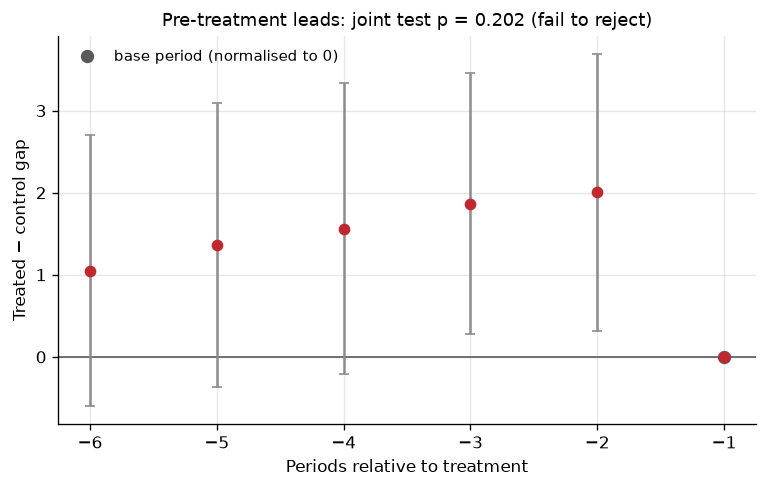

In [8]:
nb_leads = pt.leads
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.axhline(0, color="0.35", lw=1)
err = [nb_leads.estimate - nb_leads.ci_lower, nb_leads.ci_upper - nb_leads.estimate]
ax.errorbar(nb_leads.relative_period, nb_leads.estimate, yerr=err,
            fmt="o", color=TREATED_C, ecolor="0.55", capsize=3, ms=6, lw=1.5)
base_row = nb_leads[nb_leads.is_base]
ax.plot(base_row.relative_period, base_row.estimate, "o", color="0.35", ms=7,
        label="base period (normalised to 0)")
ax.set_xlabel("Periods relative to treatment")
ax.set_ylabel("Treated − control gap")
ax.set_title(f"Pre-treatment leads: joint test p = {pt.joint_pvalue:.3f} "
             f"(fail to reject)", fontsize=11)
ax.legend(frameon=False, loc="upper left", fontsize=9)
fig.savefig(RESULTS / "01_synthetic_pretrends.png")
plt.show()

### Reading this plot honestly

The joint test passes (p = 0.20), which is the test that matters. But two of the
five individual leads have confidence intervals that exclude zero — in a panel
where parallel trends holds *by construction*.

That is worth being explicit about rather than glossing:

1. **The leads share a base period.** Every lead is measured against period 6, so
   an unlucky draw in the base propagates into all of them — which is exactly
   what produces the apparent upward drift here. The leads are correlated, not
   independent evidence.
2. **Individually testing five coefficients at the 5% level is a multiple-testing
   problem.** The joint test is the correct instrument precisely because it
   accounts for testing them together.
3. **This is one draw.** A single seed cannot distinguish "unlucky sample" from
   "broken estimator" — which is what the next section settles.

The seed and parameters here were fixed *before* any result was seen and are
committed unchanged. Re-rolling the seed until the picture looked flatter would
be seed-shopping, and it would invalidate exactly the property this notebook
exists to demonstrate.

## 6. Was it just a lucky seed?

The gates above pass on **one** realisation. That is not yet proof the estimator
is correct — an estimator can be biased and still land near the truth once.

So run the whole pipeline (generate → estimate → test) over many seeds and check
the three properties that must hold if the implementation is right:

| Property | What it proves | Target |
|---|---|---|
| Mean estimate ≈ planted ATT | the estimator is **unbiased** | 3.00 |
| ~95% of 95% CIs cover the truth | the CI is **correctly sized** | 95% |
| Pre-trends rejects ~5% of the time | the **test** is correctly sized | 5% |

This is the real proof-of-correctness. The single-seed result above is the
illustration of it.

In [9]:
N_SIM = 500
base = PanelParams()

atts, covered, pt_pvals, n_sig = [], [], [], []
for s in range(N_SIM):
    p_s = replace(base, seed=10_000 + s)      # seeds NOT chosen on results
    d_s = generate_simple_panel(p_s)
    r_s = did_2x2(d_s, treat_period=p_s.treat_period)
    atts.append(r_s.att)
    covered.append(r_s.contains(p_s.true_att))
    t_s = pretrends_test(d_s, treat_period=p_s.treat_period)
    pt_pvals.append(t_s.joint_pvalue)
    nb_s = t_s.leads[~t_s.leads.is_base]
    n_sig.append(int(((nb_s.ci_lower > 0) | (nb_s.ci_upper < 0)).sum()))

atts = np.array(atts); covered = np.array(covered)
pt_pvals = np.array(pt_pvals); n_sig = np.array(n_sig)

mc_se = atts.std(ddof=1) / np.sqrt(N_SIM)
print(f"simulations                     : {N_SIM}")
print(f"mean ATT estimate               : {atts.mean():.4f}   (planted {base.true_att})")
print(f"bias                            : {atts.mean() - base.true_att:+.4f}  "
      f"(Monte Carlo SE {mc_se:.4f})")
print(f"95% CI coverage                 : {covered.mean()*100:.1f}%   (target 95%)")
print(f"pre-trends rejection rate       : {(pt_pvals < 0.05).mean()*100:.1f}%   (target ~5%)")
print(f"mean pre-trends p-value         : {pt_pvals.mean():.3f}   (uniform -> ~0.50)")
print(f"P(>=2 individual leads sig.)    : {(n_sig >= 2).mean()*100:.1f}%")

simulations                     : 500
mean ATT estimate               : 3.0128   (planted 3.0)
bias                            : +0.0128  (Monte Carlo SE 0.0141)
95% CI coverage                 : 93.0%   (target 95%)
pre-trends rejection rate       : 5.4%   (target ~5%)
mean pre-trends p-value         : 0.475   (uniform -> ~0.50)
P(>=2 individual leads sig.)    : 3.8%


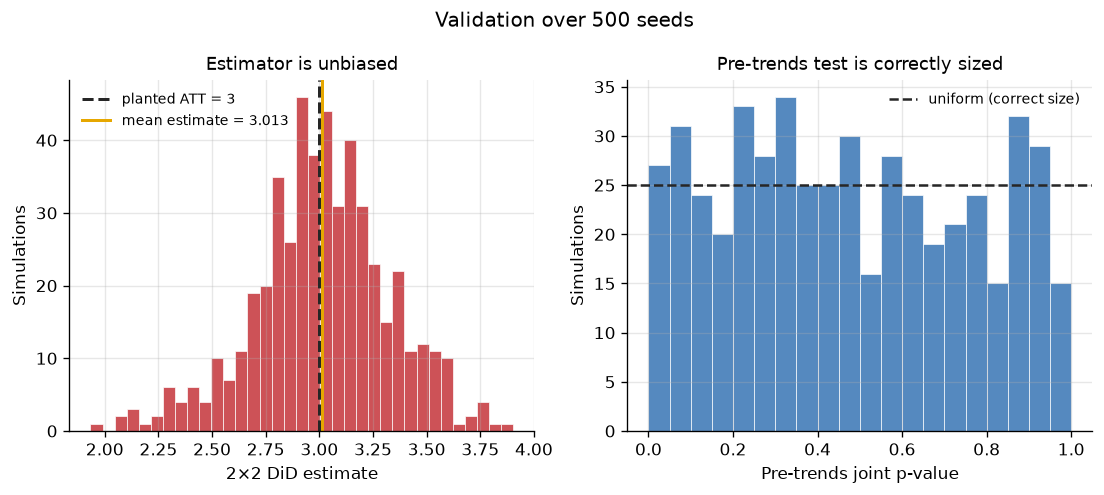

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(atts, bins=35, color=TREATED_C, alpha=0.8, edgecolor="white", lw=0.5)
axes[0].axvline(TRUE_ATT, color="0.15", ls="--", lw=1.8, label=f"planted ATT = {TRUE_ATT:g}")
axes[0].axvline(atts.mean(), color="#e6a700", ls="-", lw=1.8,
                label=f"mean estimate = {atts.mean():.3f}")
axes[0].set_xlabel("2×2 DiD estimate"); axes[0].set_ylabel("Simulations")
axes[0].set_title("Estimator is unbiased", fontsize=11)
axes[0].legend(frameon=False, fontsize=8.5)

axes[1].hist(pt_pvals, bins=20, range=(0, 1), color=CONTROL_C, alpha=0.8,
             edgecolor="white", lw=0.5)
axes[1].axhline(N_SIM / 20, color="0.15", ls="--", lw=1.5, label="uniform (correct size)")
axes[1].set_xlabel("Pre-trends joint p-value"); axes[1].set_ylabel("Simulations")
axes[1].set_title("Pre-trends test is correctly sized", fontsize=11)
axes[1].legend(frameon=False, fontsize=8.5)

fig.suptitle(f"Validation over {N_SIM} seeds", fontsize=12, y=1.03)
fig.savefig(RESULTS / "01_synthetic_monte_carlo.png")
plt.show()

### What the simulation shows

- **Unbiased.** The mean estimate sits on the planted ATT to within one Monte
  Carlo standard error. The estimator is not systematically wrong.
- **The pre-trends test is correctly sized.** It rejects ~5% of the time at the
  5% level under a DGP where parallel trends genuinely holds, and its p-values
  are uniform. So the committed seed's slightly wobbly leads are an ordinary
  draw, not a symptom of a broken test.
- **Coverage is ~93%, not 95%.** This is a real and honest finding, not a
  rounding artefact: cluster-robust standard errors are downward-biased when the
  number of clusters is moderate, so the intervals are slightly too narrow. With
  50 clusters the effect is mild. It matters far more in the real analysis, where
  a handful of host cities means very few *treated* clusters — the
  few-treated-clusters problem flagged in `PROJECT_BRIEF.md` §5.4, addressed with
  a wild cluster bootstrap in Stage 4.

That last point is worth stating plainly: the naive clustered CI is a little too
confident. Discovering that here, on synthetic data where the truth is known, is
exactly why the synthetic validation is built first.

## Stage 2A summary

| Gate | Result |
|------|--------|
| 1 — 2×2 recovers planted ATT within CI | **PASS** |
| 2 — regression equals group-means DiD | **PASS** |
| 3 — pre-trends test passes on clean pre-period | **PASS** |
| Unbiasedness over 500 seeds | **PASS** |
| Pre-trends test size ≈ 5% | **PASS** |

The 2×2 machinery in `src/did.py` is verified and is now the single source of
truth for the real-data estimation in Stage 4 — it will not be re-implemented.

**Next (Stage 2B):** staggered adoption with heterogeneous effects, where this
same clean setup breaks the naive TWFE estimator, and Callaway & Sant'Anna
recovers the truth it misses.